# Dataset 1 — Appliances Energy Prediction

Análise da amostra preparada no Orange Data Mining utilizando Python e Pandas.

## 1. Carregamento e inspeção inicial

In [1]:
import pandas as pd

dados = pd.read_csv("Appliences_Energy_Prediction_Sample.csv")
dados.head()

,Appliances,lights,T1,RH_1,T8,RH_8,T9,RH_9
0,40,0,20.8900,35.4000,23.0688,39.7475,19.29,39.03
1,90,10,21.8900,53.1000,20.6167,47.5633,16.29,44.20
2,50,0,21.3900,35.5000,22.1000,39.6267,19.39,38.29
3,50,0,21.3900,41.0333,21.2000,38.0900,20.29,38.56
4,70,0,19.9633,35.1267,22.1000,39.5900,19.00,40.70


In [2]:
dados.shape

(1974, 8)

In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T8          1974 non-null   float64
 5   RH_8        1974 non-null   float64
 6   T9          1974 non-null   float64
 7   RH_9        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [4]:
dados.describe()

,Appliances,lights,T1,RH_1,T8,RH_8,T9,RH_9
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,22.028938,42.854808,19.456805,41.498457
std,93.826149,7.937076,1.574883,3.971923,1.920160,5.259386,1.947049,4.122508
min,20.000000,0.000000,16.790000,27.733300,16.367800,30.133300,15.000000,29.200000
25%,50.000000,0.000000,20.700000,37.205825,20.790000,38.863300,18.033300,38.500000
50%,60.000000,0.000000,21.600000,39.590000,22.133300,42.400000,19.290000,40.882000
75%,100.000000,0.000000,22.600000,42.991675,23.364100,46.400000,20.545825,44.284175
max,770.000000,50.000000,26.260000,57.496700,27.050000,58.510000,24.500000,52.966700


## 2. Renomeando as colunas

In [5]:
dados = dados.rename(columns={
    "Appliances": "Consumo_Eletrodomesticos",
    "T1": "Temperatura_1",
    "RH_1": "Umidade_1",
    "T8": "Temperatura_8",
    "RH_8": "Umidade_8",
    "T9": "Temperatura_9",
    "RH_9": "Umidade_9"
})

dados.head()

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_8,Umidade_8,Temperatura_9,Umidade_9
0,40,0,20.8900,35.4000,23.0688,39.7475,19.29,39.03
1,90,10,21.8900,53.1000,20.6167,47.5633,16.29,44.20
2,50,0,21.3900,35.5000,22.1000,39.6267,19.39,38.29
3,50,0,21.3900,41.0333,21.2000,38.0900,20.29,38.56
4,70,0,19.9633,35.1267,22.1000,39.5900,19.00,40.70


## 3. Maior consumo registrado

In [6]:
maior_consumo = dados["Consumo_Eletrodomesticos"].max()
print("Maior consumo registrado:", maior_consumo)

Maior consumo registrado: 770


## 4. Limiar de 70% do consumo máximo

In [7]:
limiar_70 = maior_consumo * 0.70
print("70% do consumo máximo:", limiar_70)

70% do consumo máximo: 539.0


## 5. Registros acima de 70% do consumo máximo

In [8]:
df_consumo_alto = dados[
    dados["Consumo_Eletrodomesticos"] > limiar_70
]

df_consumo_alto

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_8,Umidade_8,Temperatura_9,Umidade_9
352,620,0,24.3900,44.3333,24.0333,45.9333,22.6000,43.5000
427,650,0,20.8900,36.7000,21.6667,40.1267,19.5000,37.9000
453,560,30,21.3567,36.0900,21.2600,37.1000,19.2900,36.0000
616,570,10,24.8900,32.6667,26.5400,34.2960,23.2360,30.8300
696,590,30,19.8567,47.6633,19.4450,37.1022,16.0000,36.6333
744,740,20,19.5000,42.1333,20.5389,39.0294,17.8900,39.7000
916,750,30,22.4300,43.0000,23.4144,45.7428,18.6000,41.5600
993,690,10,22.5333,45.0267,23.1983,43.7761,19.0667,42.9667
1026,560,0,21.0000,38.9000,22.5333,40.7300,19.2900,37.2000
1173,580,0,21.6000,34.6267,22.7900,31.0300,18.5000,38.5000


## 6. Quantidade e percentual de registros selecionados

In [9]:
quantidade_consumo_alto = len(df_consumo_alto)
percentual_consumo_alto = quantidade_consumo_alto / len(dados) * 100

print("Quantidade de registros:", quantidade_consumo_alto)
print(f"Percentual da amostra: {percentual_consumo_alto:.2f}%")

Quantidade de registros: 22
Percentual da amostra: 1.11%


## 7. Temperatura média de T1

In [10]:
temperatura_media = dados["Temperatura_1"].mean()
print(f"Temperatura média de T1: {temperatura_media:.2f} °C")

Temperatura média de T1: 21.66 °C


## 8. Consumo acima de 70% do máximo e temperatura acima da média

In [11]:
df_consumo_temperatura = dados[
    (dados["Consumo_Eletrodomesticos"] > limiar_70) &
    (dados["Temperatura_1"] > temperatura_media)
]

df_consumo_temperatura

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_8,Umidade_8,Temperatura_9,Umidade_9
352,620,0,24.3900,44.3333,24.0333,45.9333,22.6000,43.5000
616,570,10,24.8900,32.6667,26.5400,34.2960,23.2360,30.8300
916,750,30,22.4300,43.0000,23.4144,45.7428,18.6000,41.5600
993,690,10,22.5333,45.0267,23.1983,43.7761,19.0667,42.9667
1182,600,20,24.8900,48.1333,25.2000,47.2900,24.2900,46.2643
1196,580,0,23.6333,47.2267,23.8900,48.0000,22.8900,46.4333
1835,720,10,22.2000,37.9333,22.0000,39.5000,20.5000,37.8600
1964,620,0,22.7000,41.7233,22.8757,41.3614,21.2000,41.0000


In [12]:
quantidade_consumo_temperatura = len(df_consumo_temperatura)
percentual_consumo_temperatura = quantidade_consumo_temperatura / len(dados) * 100

print("Quantidade de registros:", quantidade_consumo_temperatura)
print(f"Percentual da amostra: {percentual_consumo_temperatura:.2f}%")

Quantidade de registros: 8
Percentual da amostra: 0.41%


## 9. Comparação e interpretação

In [13]:
print("Somente consumo elevado:", len(df_consumo_alto), "registros")
print("Consumo elevado + temperatura acima da média:", len(df_consumo_temperatura), "registros")
print("Diferença:", len(df_consumo_alto) - len(df_consumo_temperatura), "registros")

Somente consumo elevado: 22 registros
Consumo elevado + temperatura acima da média: 8 registros
Diferença: 14 registros


**Interpretação:**

O primeiro filtro considera apenas os momentos em que o consumo dos eletrodomésticos ficou acima de 70% do maior valor observado. Ao acrescentar a condição de temperatura de T1 acima da média, o número de registros diminui, pois passam a ser necessários dois critérios simultaneamente. Na amostra analisada, o primeiro filtro selecionou **22 registros (1,11%)**, enquanto o segundo selecionou **8 registros (0,41%)**. Portanto, nem todos os episódios de consumo elevado ocorreram quando a temperatura de T1 estava acima da média.

# ⚡ Análise de Consumo de Energia — Indústria Siderúrgica

### Dataset 2 — Steel Industry Energy Consumption (UCI)

**Objetivo:** identificar situações de **consumo elevado** e verificar se elas coincidem com
**carga máxima** ou com **fator de potência menos favorável**.

> **Amostra:** 20% do dataset original, previamente preparada no Orange Data Mining.


## 📌 Roteiro da análise

1. Carregar e preparar os dados  
2. Fazer uma inspeção inicial  
3. Encontrar o consumo máximo e o limiar de 75%  
4. Identificar registros de consumo elevado  
5. Verificar a categoria `Maximum_Load`  
6. Analisar o fator de potência  
7. Encontrar situações simultâneas de alto consumo + baixo fator de potência  
8. Tirar uma conclusão sobre os resultados


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregando a amostra exportada do Orange
df = pd.read_csv("Steel_Industry_Energy_Consumption_Sample.csv")

# Simplificando os nomes dos atributos
df = df.rename(columns={
    "Usage_kWh": "Consumo_kWh",
    "Lagging_Current_Power_Factor": "FP_Atrasado",
    "Leading_Current_Power_Factor": "FP_Adiantado"
})

print(f"Dataset carregado: {df.shape[0]:,} registros e {df.shape[1]} atributos.")


Dataset carregado: 7,008 registros e 9 atributos.


## 🔎 1. Inspeção inicial

In [14]:
# Primeiros registros
display(df.head())

# Dimensões
print("Shape:", df.shape)

# Estrutura e tipos
print("\nInformações do dataset:")
df.info()

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
display(df.describe())


,date,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,FP_Atrasado,FP_Adiantado,WeekStatus,Day_of_week,Load_Type
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


Shape: (7008, 9)

Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  7008 non-null   str    
 1   Consumo_kWh                           7008 non-null   float64
 2   Lagging_Current_Reactive.Power_kVarh  7008 non-null   float64
 3   Leading_Current_Reactive_Power_kVarh  7008 non-null   float64
 4   FP_Atrasado                           7008 non-null   float64
 5   FP_Adiantado                          7008 non-null   float64
 6   WeekStatus                            7008 non-null   str    
 7   Day_of_week                           7008 non-null   str    
 8   Load_Type                             7008 non-null   str    
dtypes: float64(5), str(4)
memory usage: 492.9 KB

Estatísticas descritivas:


,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,FP_Atrasado,FP_Adiantado
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


## 🧹 2. Verificação de valores ausentes

In [15]:
nulos = df.isnull().sum()

display(nulos.to_frame("Valores ausentes"))

print(f"Total de valores ausentes: {nulos.sum()}")

if nulos.sum() == 0:
    print("✅ Não existem valores ausentes no dataset.")
else:
    print("⚠️ Existem valores ausentes e eles devem ser investigados.")


,Valores ausentes
date,0
Consumo_kWh,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0
FP_Atrasado,0
FP_Adiantado,0
WeekStatus,0
Day_of_week,0
Load_Type,0


Total de valores ausentes: 0
✅ Não existem valores ausentes no dataset.


## 🚨 3. Consumo elevado

In [16]:
consumo_maximo = df["Consumo_kWh"].max()
limiar = consumo_maximo * 0.75

print(f"Consumo máximo registrado: {consumo_maximo:.2f} kWh")
print(f"Limiar de 75% do máximo: {limiar:.2f} kWh")

# Registros acima do limiar
consumo_alto = df[df["Consumo_kWh"] > limiar].copy()

quantidade = len(consumo_alto)
percentual = quantidade / len(df) * 100

print(f"\nRegistros com consumo elevado: {quantidade}")
print(f"Percentual da amostra: {percentual:.2f}%")

display(
    consumo_alto[
        ["Consumo_kWh", "WeekStatus", "Day_of_week", "Load_Type"]
    ].sort_values("Consumo_kWh", ascending=False).head(10)
)


Consumo máximo registrado: 153.14 kWh
Limiar de 75% do máximo: 114.85 kWh

Registros com consumo elevado: 129
Percentual da amostra: 1.84%


,Consumo_kWh,WeekStatus,Day_of_week,Load_Type
744,153.14,Weekday,Monday,Medium_Load
4791,149.18,Weekday,Wednesday,Medium_Load
531,146.88,Weekday,Monday,Maximum_Load
1284,146.34,Weekday,Friday,Medium_Load
2004,146.27,Weekday,Monday,Medium_Load
7005,145.51,Weekday,Thursday,Maximum_Load
6444,143.93,Weekday,Thursday,Maximum_Load
5144,143.82,Weekday,Wednesday,Medium_Load
825,141.66,Weekday,Thursday,Maximum_Load
4800,140.80,Weekday,Wednesday,Maximum_Load


## 📊 4. Distribuição do consumo

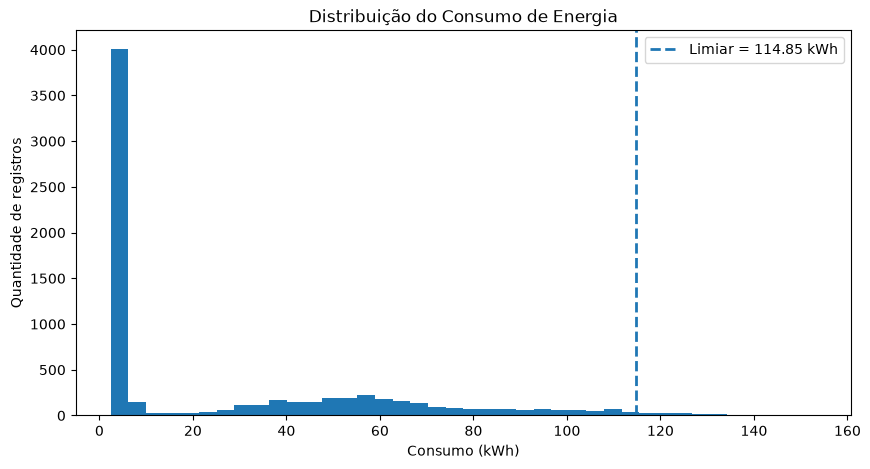

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df["Consumo_kWh"], bins=40)
plt.axvline(limiar, linestyle="--", linewidth=2, label=f"Limiar = {limiar:.2f} kWh")
plt.xlabel("Consumo (kWh)")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição do Consumo de Energia")
plt.legend()
plt.show()


## 🏭 5. Consumo elevado e categoria `Maximum_Load`

In [18]:
maximum_load = consumo_alto[
    consumo_alto["Load_Type"] == "Maximum_Load"
].copy()

qtd_maximum = len(maximum_load)
percentual_maximum = qtd_maximum / len(consumo_alto) * 100

print(f"Registros de consumo elevado em Maximum_Load: {qtd_maximum}")
print(f"Percentual dos registros de consumo elevado: {percentual_maximum:.2f}%")

display(
    consumo_alto["Load_Type"]
    .value_counts()
    .rename_axis("Load_Type")
    .reset_index(name="Quantidade")
)


Registros de consumo elevado em Maximum_Load: 62
Percentual dos registros de consumo elevado: 48.06%


,Load_Type,Quantidade
0,Maximum_Load,62
1,Medium_Load,58
2,Light_Load,9


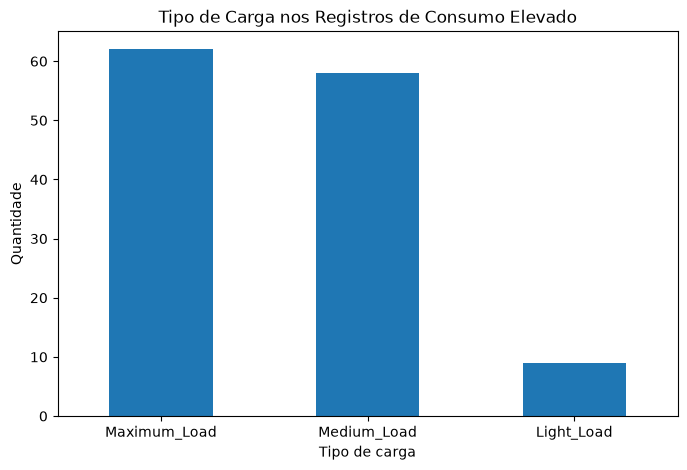

In [19]:
# Comparação visual entre os tipos de carga
load_counts = consumo_alto["Load_Type"].value_counts()

plt.figure(figsize=(8, 5))
load_counts.plot(kind="bar")
plt.xlabel("Tipo de carga")
plt.ylabel("Quantidade")
plt.title("Tipo de Carga nos Registros de Consumo Elevado")
plt.xticks(rotation=0)
plt.show()


## ⚙️ 6. Análise do fator de potência

Será utilizado o **fator de potência atrasado (`FP_Atrasado`)**.

Como referência, será adotado o limite de **90**:

> Valores de `FP_Atrasado < 90` serão tratados como valores relativamente menos favoráveis para esta análise.


Estatísticas do fator de potência atrasado:


count    7008.000000
mean       80.672277
std        18.869855
min        37.870000
25%        63.602500
50%        87.990000
75%        98.842500
max       100.000000
Name: FP_Atrasado, dtype: float64


Limite escolhido para FP_Atrasado: 90


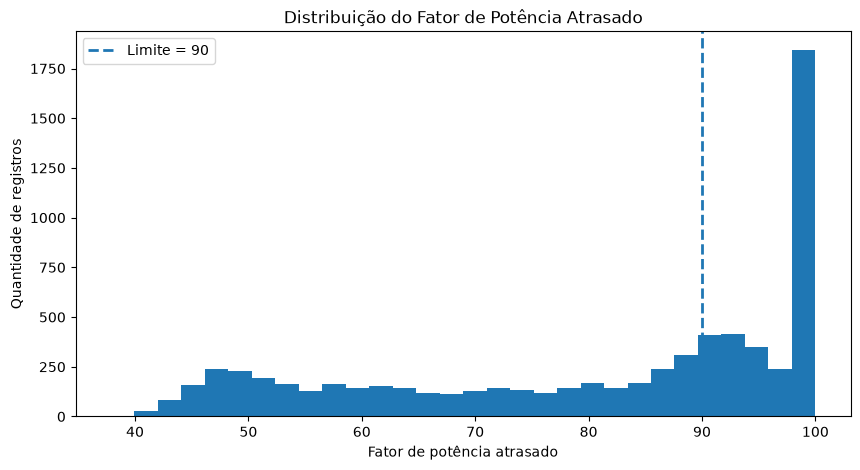

In [20]:
print("Estatísticas do fator de potência atrasado:")
display(df["FP_Atrasado"].describe())

limite_fp = 90

print(f"\nLimite escolhido para FP_Atrasado: {limite_fp}")

plt.figure(figsize=(10, 5))
plt.hist(df["FP_Atrasado"], bins=30)
plt.axvline(limite_fp, linestyle="--", linewidth=2, label="Limite = 90")
plt.xlabel("Fator de potência atrasado")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição do Fator de Potência Atrasado")
plt.legend()
plt.show()


## 🚨⚙️ 7. Alto consumo + fator de potência abaixo de 90

In [21]:
# Aplicando as duas condições simultaneamente
problemas = df[
    (df["Consumo_kWh"] > limiar) &
    (df["FP_Atrasado"] < limite_fp)
].copy()

quantidade_final = len(problemas)
percentual_final = quantidade_final / len(df) * 100

print(f"Registros encontrados: {quantidade_final}")
print(f"Percentual da amostra: {percentual_final:.2f}%")

display(
    problemas[
        [
            "Consumo_kWh",
            "FP_Atrasado",
            "FP_Adiantado",
            "WeekStatus",
            "Day_of_week",
            "Load_Type"
        ]
    ].sort_values("Consumo_kWh", ascending=False)
)


Registros encontrados: 42
Percentual da amostra: 0.60%


,Consumo_kWh,FP_Atrasado,FP_Adiantado,WeekStatus,Day_of_week,Load_Type
4791,149.18,89.45,100.0,Weekday,Wednesday,Medium_Load
2004,146.27,88.54,100.0,Weekday,Monday,Medium_Load
7005,145.51,87.13,100.0,Weekday,Thursday,Maximum_Load
6444,143.93,89.39,100.0,Weekday,Thursday,Maximum_Load
4800,140.80,89.60,100.0,Weekday,Wednesday,Maximum_Load
605,134.60,89.72,100.0,Weekday,Monday,Maximum_Load
2830,132.77,88.19,100.0,Weekday,Thursday,Maximum_Load
771,132.30,88.37,100.0,Weekend,Saturday,Medium_Load
4166,131.65,88.92,100.0,Weekday,Tuesday,Maximum_Load
5739,130.54,85.90,100.0,Weekday,Monday,Light_Load


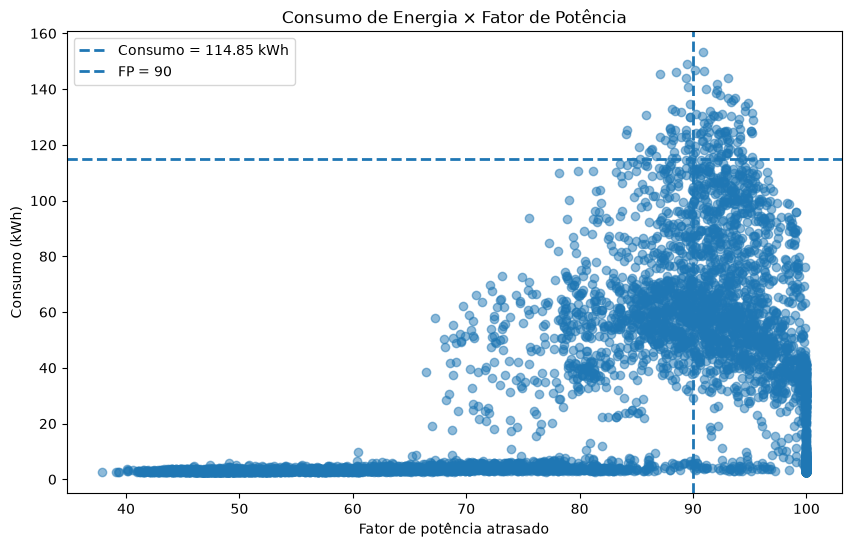

In [22]:
# Relação entre consumo e fator de potência
plt.figure(figsize=(10, 6))
plt.scatter(df["FP_Atrasado"], df["Consumo_kWh"], alpha=0.5)
plt.axhline(limiar, linestyle="--", linewidth=2, label=f"Consumo = {limiar:.2f} kWh")
plt.axvline(limite_fp, linestyle="--", linewidth=2, label="FP = 90")
plt.xlabel("Fator de potência atrasado")
plt.ylabel("Consumo (kWh)")
plt.title("Consumo de Energia × Fator de Potência")
plt.legend()
plt.show()


# 📝 8. Conclusão

Os registros classificados como **consumo elevado** representam situações em que o consumo
ultrapassa **75% do maior consumo observado**. Na amostra analisada, foram encontrados
**129 registros**, correspondentes a aproximadamente **1,84%** dos dados.

Desses registros, **62 pertencem à categoria `Maximum_Load`**, mostrando que uma parcela
importante dos maiores consumos está associada à condição de carga máxima.

Ao combinar consumo elevado com **`FP_Atrasado < 90`**, foram identificados **42 registros**,
equivalentes a aproximadamente **0,60% da amostra**.

Esses casos merecem atenção porque combinam **alta demanda energética** com um **fator de
potência menos favorável**. A equipe de energia pode investigar esses períodos para identificar
equipamentos ou processos que estejam aumentando a demanda e reduzindo a eficiência da
utilização da energia elétrica.

### 🎯 Principais resultados

| Indicador | Resultado |
|---|---:|
| Registros analisados | **7.008** |
| Consumo máximo | **153,14 kWh** |
| Limiar de 75% | **114,86 kWh** |
| Consumo elevado | **129 (1,84%)** |
| `Maximum_Load` entre consumo elevado | **62** |
| Limite de fator de potência | **90** |
| Alto consumo + FP < 90 | **42 (0,60%)** |

**Conclusão:** os 42 registros finais podem ser tratados como **pontos prioritários de
investigação energética**, pois reúnem simultaneamente alta demanda e condição menos favorável
de fator de potência.


# Dataset 3 — Power Consumption of Tetouan City

## Etapa B — Python / Pandas



## Preparação dos dados

In [1]:
import pandas as pd

# Leitura da amostra exportada pelo Orange
df = pd.read_csv("Power_Consumption_of_Tetouan_City.csv")

print(f"Quantidade de registros da amostra: {len(df)}")
df.head()

Quantidade de registros da amostra: 7863


,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Temperature,Humidity,Wind Speed
0,32985.1,19396.7,17623.3,22.76,29.73,0.085
1,34737.6,29803.0,14417.3,15.92,54.44,0.085
2,27894.7,20808.5,16458.8,15.08,57.23,0.076
3,42476.9,23634.1,25089.7,12.42,72.30,0.081
4,21341.1,12006.1,11531.6,14.58,80.60,0.080


## 1. Renomear as três variáveis de consumo

As colunas de consumo serão renomeadas para `Consumo_Zona_1`, `Consumo_Zona_2` e `Consumo_Zona_3`.

In [2]:
df = df.rename(columns={
    "Zone 1 Power Consumption": "Consumo_Zona_1",
    "Zone 2  Power Consumption": "Consumo_Zona_2",
    "Zone 3  Power Consumption": "Consumo_Zona_3"
})

df.columns

Index(['Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3', 'Temperature',
       'Humidity', 'Wind Speed'],
      dtype='object')

## 2. Determinar o consumo máximo registrado em cada zona

In [3]:
maximos = df[[
    "Consumo_Zona_1",
    "Consumo_Zona_2",
    "Consumo_Zona_3"
]].max()

maximos

Consumo_Zona_1    51571.5
Consumo_Zona_2    36437.2
Consumo_Zona_3    47441.7
dtype: float64

**Resultado:** os valores máximos encontrados foram:

- Zona 1: **51571.5**
- Zona 2: **36437.2**
- Zona 3: **47441.7**

## 3. Identificar a zona com o maior pico de consumo

In [4]:
zona_maior = maximos.idxmax()
valor_maximo = maximos.max()

print("Zona com maior pico:", zona_maior)
print("Valor do maior pico:", valor_maximo)

Zona com maior pico: Consumo_Zona_1
Valor do maior pico: 51571.5


**Interpretação:** a **Zona 1** apresentou o maior pico de consumo da amostra, com valor máximo de **51571.5**.

## 4. Calcular 70% do valor máximo e criar um DataFrame com registros acima do limiar

In [5]:
limiar = 0.70 * valor_maximo

df_acima_limiar = df[df[zona_maior] > limiar].copy()

print(f"70% do valor máximo: {limiar:.2f}")
df_acima_limiar.head()

70% do valor máximo: 36100.05


,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3,Temperature,Humidity,Wind Speed
3,42476.9,23634.1,25089.7,12.42,72.30,0.081
8,37286.7,30716.2,15834.8,14.66,65.92,0.075
12,40993.9,25383.4,24960.0,21.03,86.50,0.068
14,37475.2,24276.2,25140.6,27.06,47.58,4.905
19,40676.0,24754.7,25095.9,19.20,65.81,4.924


**Interpretação:** 70% do maior pico corresponde a **36100.05**. O DataFrame `df_acima_limiar` contém somente os registros em que o consumo da Zona 1 ficou acima desse valor.

## 5. Contar os registros e calcular o percentual que eles representam

In [6]:
qtd_acima_limiar = len(df_acima_limiar)
percentual_acima_limiar = (qtd_acima_limiar / len(df)) * 100

print("Quantidade de registros acima do limiar:", qtd_acima_limiar)
print(f"Percentual da amostra: {percentual_acima_limiar:.2f}%")

Quantidade de registros acima do limiar: 2388
Percentual da amostra: 30.37%


**Interpretação:** existem **2388 registros** acima de 70% do pico máximo, correspondendo a **30.37%** dos registros da amostra.

## 6. Calcular a temperatura média e criar um segundo DataFrame

O segundo conjunto mantém simultaneamente:
- consumo da Zona 1 acima do limiar de 70% do pico; e
- temperatura acima da média da amostra.

In [7]:
temperatura_media = df["Temperature"].mean()

df_acima_limiar_temp = df[
    (df[zona_maior] > limiar) &
    (df["Temperature"] > temperatura_media)
].copy()

print(f"Temperatura média: {temperatura_media:.2f}")
print("Quantidade de registros após incluir a condição de temperatura:",
      len(df_acima_limiar_temp))

df_acima_limiar_temp.head()

Temperatura média: 18.79
Quantidade de registros após incluir a condição de temperatura: 1597


,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3,Temperature,Humidity,Wind Speed
12,40993.9,25383.4,24960.0,21.03,86.50,0.068
14,37475.2,24276.2,25140.6,27.06,47.58,4.905
19,40676.0,24754.7,25095.9,19.20,65.81,4.924
21,40256.1,27416.3,25453.5,27.11,43.35,4.906
25,36511.9,25906.3,25654.9,26.92,70.20,4.909


**Interpretação:** a temperatura média da amostra é de aproximadamente **18.79 °C**. Ao exigir também temperatura acima dessa média, restaram **1597 registros**.

## 7. Comparar os dois conjuntos e interpretar a mudança na quantidade de registros

In [8]:
qtd_antes = len(df_acima_limiar)
qtd_depois = len(df_acima_limiar_temp)

percentual_antes = (qtd_antes / len(df)) * 100
percentual_depois = (qtd_depois / len(df)) * 100

reducao = qtd_antes - qtd_depois
reducao_percentual = (reducao / qtd_antes) * 100

print(f"Registros apenas com consumo acima do limiar: {qtd_antes}")
print(f"Registros com consumo acima do limiar e temperatura acima da média: {qtd_depois}")
print(f"Redução na quantidade de registros: {reducao}")
print(f"Redução relativa ao primeiro conjunto: {reducao_percentual:.2f}%")
print(f"Percentual da amostra antes: {percentual_antes:.2f}%")
print(f"Percentual da amostra depois: {percentual_depois:.2f}%")

Registros apenas com consumo acima do limiar: 2388
Registros com consumo acima do limiar e temperatura acima da média: 1597
Redução na quantidade de registros: 791
Redução relativa ao primeiro conjunto: 33.12%
Percentual da amostra antes: 30.37%
Percentual da amostra depois: 20.31%


### Resposta interpretativa

O primeiro DataFrame contém **2388 registros**, equivalentes a **30.37%** da amostra, considerando somente o consumo da Zona 1 acima de 70% do seu pico máximo.

Depois da inclusão da condição ambiental de **temperatura acima da média (18.79 °C)**, o segundo DataFrame passa a ter **1597 registros**, equivalentes a **20.31%** da amostra.

Portanto, a inclusão da condição de temperatura eliminou **791 registros**, uma redução de aproximadamente **33.12%** em relação ao primeiro conjunto. Isso mostra que **nem todos os momentos de consumo elevado ocorreram quando a temperatura estava acima da média**. A condição ambiental tornou o filtro mais restritivo e selecionou apenas os períodos em que as duas condições ocorreram simultaneamente.

# Dataset 4 — Solar Power Generation Data (Kaggle)
## Etapa B — Python / Pandas

**Situação:** a equipe de operação da usina fotovoltaica quer localizar os períodos de alta geração e identificar quais inversores (SOURCE_KEY) aparecem com maior frequência nesses momentos, trabalhando apenas com o arquivo de geração da planta (sem juntar com o arquivo de sensores).

Este notebook parte da amostra de 20% já exportada do Orange Data Mining (Etapa A) e realiza toda a Etapa B.

In [1]:
import pandas as pd

# Carrega a amostra de 20% exportada do Orange (Etapa A)
df = pd.read_csv('amostra_geracao_planta.csv')

# Renomeia as principais variáveis para nomes mais claros
df = df.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria',
    'TOTAL_YIELD': 'Geracao_Total'
})

# Garante que DATE_TIME é reconhecido como data/hora
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

df.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.613,724.827,2209.60,1.215480e+09
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.000,0.000,7220.00,8.384430e+08
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.000,0.000,4844.00,3.741710e+05
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.000,0.000,3421.00,2.356530e+06


### 2. Visão geral do dataset — `head()`, `shape`, `info()` e `describe()`

In [2]:
df.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.613,724.827,2209.60,1.215480e+09
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.000,0.000,7220.00,8.384430e+08
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.000,0.000,4844.00,3.741710e+05
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.000,0.000,3421.00,2.356530e+06


In [3]:
df.shape

(13540, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13540 entries, 0 to 13539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATE_TIME       13540 non-null  datetime64[us]
 1   SOURCE_KEY      13540 non-null  str           
 2   Potencia_CC     13540 non-null  float64       
 3   Potencia_CA     13540 non-null  float64       
 4   Geracao_Diaria  13540 non-null  float64       
 5   Geracao_Total   13540 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 634.8 KB


In [5]:
df.describe()

,DATE_TIME,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
count,13540,13540.000000,13540.000000,13540.000000,1.354000e+04
mean,2020-06-01 12:18:25.856720,244.934106,239.550853,3307.097232,6.478274e+08
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,0.000000e+00
25%,2020-05-24 00:00:00,0.000000,0.000000,271.724000,1.996630e+07
50%,2020-06-02 01:00:00,0.000000,0.000000,2930.235000,2.826160e+08
75%,2020-06-09 23:18:45,444.312500,435.801250,5556.000000,1.348470e+09
max,2020-06-17 23:45:00,1401.310000,1366.260000,9873.000000,2.247920e+09
std,NaN,369.464843,361.031313,2932.391403,7.206826e+08


**Leitura rápida:** o `describe()` já deixa à mostra o que o roteiro pede que se observe na Etapa A — há registros com `Potencia_CA` igual a zero (mínimo = 0, provavelmente períodos noturnos ou de inversor parado) e uma faixa ampla de valores até o máximo registrado, o que é esperado em dados de geração solar ao longo do dia.

### 3. Maior potência CA registrada

In [6]:
maior_potencia_ca = df['Potencia_CA'].max()
print(f'Maior Potência CA registrada na amostra: {maior_potencia_ca:.2f}')

Maior Potência CA registrada na amostra: 1366.26


### 4. Limiar de alta geração (70% da potência CA máxima)

In [7]:
limiar_70pct = 0.70 * maior_potencia_ca
print(f'Limiar de alta geração (70% do máximo): {limiar_70pct:.2f}')

Limiar de alta geração (70% do máximo): 956.38


### 5. DataFrame de alta geração — quantidade e percentual

In [8]:
df_alta_geracao = df[df['Potencia_CA'] > limiar_70pct]

qtd_alta_geracao = df_alta_geracao.shape[0]
total_registros = df.shape[0]
percentual_alta_geracao = (qtd_alta_geracao / total_registros) * 100

print(f'Registros de alta geração: {qtd_alta_geracao}')
print(f'Total de registros na amostra: {total_registros}')
print(f'Percentual de alta geração: {percentual_alta_geracao:.2f}%')

Registros de alta geração: 1019
Total de registros na amostra: 13540
Percentual de alta geração: 7.53%


### 6. Frequência dos inversores (`SOURCE_KEY`) nos registros de alta geração

In [9]:
contagem_inversores = df_alta_geracao['SOURCE_KEY'].value_counts()
contagem_inversores

SOURCE_KEY
oZ35aAeoifZaQzV    74
Mx2yZCDsyf6DPfv    67
oZZkBaNadn6DNKz    65
Qf4GUc1pJu5T6c6    60
V94E5Ben1TlhnDV    59
4UPUqMRk7TRMgml    59
WcxssY2VbP4hApt    54
vOuJvMaM2sgwLmb    52
IQ2d7wF4YD8zU1Q    52
9kRcWv60rDACzjR    52
mqwcsP2rE7J0TFp    50
PeE6FRyGXUgsRhN    50
xoJJ8DcxJEcupym    48
81aHJ1q11NBPMrL    46
LlT2YUhhzqhg5Sw    45
xMbIugepa2P7lBB    44
q49J1IKaHRwDQnt    32
NgDl19wMapZy17u    31
rrq4fwE8jgrTyWY    28
Et9kgGMDl729KT4    25
LYwnQax7tkwH5Cb    20
Quc1TzYxW2pYoWX     6
Name: count, dtype: int64

### 7. Inversor mais frequente em alta geração — interpretação

In [10]:
inversor_mais_frequente = contagem_inversores.idxmax()
qtd_inversor_mais_frequente = contagem_inversores.max()
percentual_do_inversor = (qtd_inversor_mais_frequente / qtd_alta_geracao) * 100

print(f'Inversor mais frequente nos registros de alta geração: {inversor_mais_frequente}')
print(f'Aparece {qtd_inversor_mais_frequente} vezes, ou seja, {percentual_do_inversor:.2f}% dos registros de alta geração da amostra')

Inversor mais frequente nos registros de alta geração: oZ35aAeoifZaQzV
Aparece 74 vezes, ou seja, 7.26% dos registros de alta geração da amostra


**Resposta interpretativa:**

O inversor identificado acima é o que mais aparece registrando potência CA acima do limiar de 70% do máximo observado na amostra. Isso indica apenas que esse `SOURCE_KEY` teve, proporcionalmente, mais leituras dentro da faixa de alta geração dentro deste recorte amostral — não é possível, só com esse resultado, concluir que esse inversor "tem melhor desempenho" ou que os demais "têm problema".

Isso porque:
- A amostra é de apenas 20% dos registros originais, obtida por amostragem aleatória, então a frequência de cada inversor pode variar apenas por efeito do acaso da amostragem.
- Não se sabe, neste recorte, quantos registros cada inversor tem no total (um inversor pode aparecer mais vezes em alta geração simplesmente por ter mais registros na amostra como um todo, e não por gerar mais).
- Fatores como período do dia, condições de irradiação solar e eventuais sombreamentos/localização física do inversor na planta não foram controlados nesta análise.
- Não houve cruzamento com o arquivo de sensores (irradiação, temperatura), então não é possível relacionar a alta geração às condições ambientais reais no momento.

Ou seja, o resultado serve como um indício exploratório — um ponto de partida para investigar esse inversor com mais profundidade (por exemplo, normalizando pela quantidade total de registros de cada `SOURCE_KEY` e cruzando com dados de sensores) e não como uma conclusão de desempenho ou falha.

In [1]:
import pandas as pd

# ============================================================
# DATASET 5 - WIND & SOLAR ENERGY PRODUCTION
# ============================================================

dados = pd.read_csv("Wind_&_Solar_Energy_Production_Sample.csv")

# ============================================================
# 1. INSPEÇÃO INICIAL
# ============================================================

print("PRIMEIROS REGISTROS:")
print(dados.head())

print("\nDIMENSÕES DO DATASET:")
print(dados.shape)

print("\nINFORMAÇÕES DO DATASET:")
dados.info()

print("\nESTATÍSTICAS DESCRITIVAS:")
print(dados.describe())

print("\nNOMES DAS COLUNAS:")
print(dados.columns.tolist())

# ============================================================
# 2. VERIFICAÇÃO DE VALORES AUSENTES
# ============================================================

print("\nVALORES AUSENTES:")
print(dados.isnull().sum())

# ============================================================
# 3. RENOMEAR A VARIÁVEL DE PRODUÇÃO
# ============================================================

dados = dados.rename(columns={
    "Production": "Producao"
})

print("\nCOLUNAS APÓS A RENOMEAÇÃO:")
print(dados.columns.tolist())

# ============================================================
# 4. VALORES MÍNIMO E MÁXIMO DA PRODUÇÃO
# ============================================================

producao_minima = dados["Producao"].min()
producao_maxima = dados["Producao"].max()

print("\nPRODUÇÃO MÍNIMA:")
print(producao_minima)

print("\nPRODUÇÃO MÁXIMA:")
print(producao_maxima)

# ============================================================
# 5. LIMITE DE 70% DO VALOR MÁXIMO
# ============================================================

limite_70 = 0.70 * producao_maxima

print("\nLIMITE DE 70% DO VALOR MÁXIMO:")
print(limite_70)

# ============================================================
# 6. REGISTROS DE ALTA PRODUÇÃO
# ============================================================

df_alta = dados[
    dados["Producao"] > limite_70
].copy()

quantidade_alta = len(df_alta)

percentual_alta = (
    quantidade_alta / len(dados)
) * 100

print("\nREGISTROS ACIMA DE 70% DO MÁXIMO:")
print(df_alta.head())

print("\nQUANTIDADE DE REGISTROS:")
print(quantidade_alta)

print(f"\nPERCENTUAL DA AMOSTRA: {percentual_alta:.2f}%")

# ============================================================
# 7. ANÁLISE POR ESTAÇÃO
# ============================================================

print("\nQUANTIDADE DE REGISTROS DE ALTA PRODUÇÃO POR ESTAÇÃO:")
print(df_alta["Season"].value_counts())

# ============================================================
# 8. ANÁLISE POR MÊS
# ============================================================

print("\nQUANTIDADE DE REGISTROS DE ALTA PRODUÇÃO POR MÊS:")
print(df_alta["Month_Name"].value_counts())

# ============================================================
# 9. ANÁLISE POR DIA DA SEMANA
# ============================================================

print("\nQUANTIDADE DE REGISTROS DE ALTA PRODUÇÃO POR DIA DA SEMANA:")
print(df_alta["Day_Name"].value_counts())

# ============================================================
# 10. INTERPRETAÇÃO
# ============================================================

print("\nINTERPRETAÇÃO:")

print(
    "O arquivo utilizado possui uma única variável de produção, "
    "denominada Production. Portanto, não existem colunas separadas "
    "para geração solar e geração eólica."
)

print(
    f"A produção máxima encontrada foi de {producao_maxima}, "
    f"e 70% desse valor corresponde a {limite_70:.2f}."
)

print(
    f"Foram encontrados {quantidade_alta} registros acima de 70% "
    f"do valor máximo, representando {percentual_alta:.2f}% "
    f"da amostra."
)

print(
    "Como o arquivo não apresenta as variáveis de geração solar "
    "e eólica separadamente, não é possível calcular os máximos "
    "individuais das duas fontes nem comparar a frequência de "
    "alta geração solar e eólica."
)

print(
    "A análise realizada considera a variável Production como "
    "produção de energia disponível no arquivo."
)

print(
    "Não é adequado atribuir essa variável exclusivamente à "
    "geração solar ou exclusivamente à geração eólica sem "
    "informação adicional sobre a origem dos dados."
)


PRIMEIROS REGISTROS:
                  Date  Day_Name Month_Name  Season  Day_of_Year  Start_Hour  \
0  2022-12-18 00:00:00    Sunday   December  Winter          352          21   
1  2024-01-29 00:00:00    Monday    January  Winter           29          14   
2  2024-08-01 00:00:00  Thursday     August  Summer          214          15   
3  2020-11-10 00:00:00   Tuesday   November    Fall          315           1   
4  2022-12-19 00:00:00    Monday   December  Winter          353           1   

   End_Hour  Production  
0        22       11400  
1        15        7917  
2        16        8835  
3         2         989  
4         2       12526  

DIMENSÕES DO DATASET:
(10373, 8)

INFORMAÇÕES DO DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 10373 entries, 0 to 10372
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         10373 non-null  str  
 1   Day_Name     10373 non-null  str  
 2   Month_Name   10373 no

In [1]:
import pandas as pd

# ============================================================
# DATASET 6 - INDIVIDUAL HOUSEHOLD ELECTRIC POWER CONSUMPTION
# ============================================================

# Carregar o dataset
dados = pd.read_csv(
    "Individual_Household_Eletric_Power_Consumption_Sample.csv"
)

# ============================================================
# 1. INSPEÇÃO INICIAL
# ============================================================

print("PRIMEIROS REGISTROS:")
print(dados.head())

print("\nDIMENSÕES DO DATASET:")
print(dados.shape)

print("\nINFORMAÇÕES DO DATASET:")
dados.info()

print("\nESTATÍSTICAS DESCRITIVAS:")
print(dados.describe())

# ============================================================
# 2. RENOMEAR OS ATRIBUTOS
# ============================================================

dados = dados.rename(columns={
    "Global_active_power": "Potencia_Ativa",
    "Global_reactive_power": "Potencia_Reativa",
    "Voltage": "Tensao",
    "Global_intensity": "Corrente",
    "Sub_metering_1": "Submedicao_1",
    "Sub_metering_2": "Submedicao_2",
    "Sub_metering_3": "Submedicao_3"
})

print("\nCOLUNAS APÓS A RENOMEAÇÃO:")
print(dados.columns.tolist())

# ============================================================
# 3. VERIFICAR VALORES AUSENTES
# ============================================================

print("\nVALORES AUSENTES:")
print(dados.isnull().sum())

# Tratamento dos valores ausentes
dados = dados.dropna()

print("\nDIMENSÕES APÓS O TRATAMENTO DOS VALORES AUSENTES:")
print(dados.shape)

# ============================================================
# 4. MAIOR VALOR DE POTÊNCIA ATIVA
# ============================================================

maximo = dados["Potencia_Ativa"].max()

print("\nVALOR MÁXIMO DE POTÊNCIA ATIVA:")
print(maximo)

# ============================================================
# 5. CALCULAR 75% DO VALOR MÁXIMO
# ============================================================

limite_75 = 0.75 * maximo

print("\nLIMITE DE 75% DO VALOR MÁXIMO:")
print(limite_75)

# ============================================================
# 6. REGISTROS ACIMA DE 75% DO MÁXIMO
# ============================================================

df_alta = dados[
    dados["Potencia_Ativa"] > limite_75
]

quantidade_alta = len(df_alta)

percentual_alta = (
    quantidade_alta / len(dados)
) * 100

print("\nREGISTROS COM POTÊNCIA ATIVA ACIMA DE 75% DO MÁXIMO:")
print(df_alta.head())

print("\nQUANTIDADE DE REGISTROS:")
print(quantidade_alta)

print(f"\nPERCENTUAL DA AMOSTRA: {percentual_alta:.2f}%")

# ============================================================
# 7. CORRENTE MÉDIA DA AMOSTRA
# ============================================================

corrente_media = dados["Corrente"].mean()

print("\nCORRENTE MÉDIA DA AMOSTRA:")
print(corrente_media)

# ============================================================
# 8. POTÊNCIA ACIMA DE 75% + CORRENTE ACIMA DA MÉDIA
# ============================================================

df_alta_corrente = dados[
    (dados["Potencia_Ativa"] > limite_75) &
    (dados["Corrente"] > corrente_media)
]

quantidade_alta_corrente = len(df_alta_corrente)

percentual_alta_corrente = (
    quantidade_alta_corrente / len(dados)
) * 100

print(
    "\nREGISTROS COM POTÊNCIA ACIMA DE 75% "
    "E CORRENTE ACIMA DA MÉDIA:"
)

print(df_alta_corrente.head())

print("\nQUANTIDADE DE REGISTROS:")
print(quantidade_alta_corrente)

print(
    f"\nPERCENTUAL DA AMOSTRA: "
    f"{percentual_alta_corrente:.2f}%"
)

# ============================================================
# 9. COMPARAÇÃO DOS DOIS CONJUNTOS
# ============================================================

print("\nCOMPARAÇÃO DOS CONJUNTOS:")

print(
    f"Potência acima de 75%: "
    f"{quantidade_alta} registros "
    f"({percentual_alta:.2f}%)"
)

print(
    f"Potência acima de 75% + corrente acima da média: "
    f"{quantidade_alta_corrente} registros "
    f"({percentual_alta_corrente:.2f}%)"
)

# ============================================================
# 10. INTERPRETAÇÃO
# ============================================================

print("\nINTERPRETAÇÃO:")

if quantidade_alta_corrente == quantidade_alta:

    print(
        "A inclusão da corrente acima da média não alterou "
        "a quantidade de registros selecionados."
    )

    print(
        "Foram encontrados 58 registros com potência ativa "
        "acima de 75% do valor máximo e os mesmos 58 registros "
        "também apresentaram corrente acima da média."
    )

    print(
        "Isso indica que, nesta amostra, todos os registros "
        "classificados como de alta potência também apresentaram "
        "corrente acima do comportamento médio."
    )

    print(
        "Portanto, embora a segunda condição torne o critério "
        "mais específico, ela não eliminou nenhum registro "
        "nesta amostra."
    )

else:

    print(
        "A inclusão da corrente acima da média reduziu a "
        "quantidade de registros selecionados."
    )

    print(
        "Isso ocorre porque o segundo conjunto exige que "
        "as duas condições sejam satisfeitas simultaneamente: "
        "potência ativa acima de 75% do máximo e corrente "
        "acima da média."
    )

print(
    "\nEsses registros podem merecer maior atenção na análise "
    "do consumo elétrico, pois apresentam simultaneamente "
    "potência ativa elevada e corrente acima do comportamento "
    "médio da amostra."
)

print(
    "Entretanto, esse resultado isoladamente não permite "
    "afirmar que exista uma falha ou problema elétrico."
)


PRIMEIROS REGISTROS:
   Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
0                1.502                  0.074   240.17               6.4   
1                0.374                  0.264   245.50               1.8   
2                0.620                  0.300   239.85               3.0   
3                0.280                  0.200   235.72               1.4   
4                1.372                  0.054   243.95               5.6   

   Sub_metering_1  Sub_metering_2  Sub_metering_3  
0               0               0              18  
1               0               2               0  
2               0               1               1  
3               0               0               0  
4               0               0              18  

DIMENSÕES DO DATASET:
(204928, 7)

INFORMAÇÕES DO DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 204928 entries, 0 to 204927
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 